In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
import torch
import tiktoken
from utility import token_ids_to_text, text_to_token_ids
from model.architecture import generate_text_simple, GPTModelFlashAttn
from model.dummy_model import load_yaml

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
config = load_yaml("../model/config/model_config_train.yaml")["model"]
model = GPTModelFlashAttn(config)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=config["context_length"]
)
print(f"Output text: {token_ids_to_text(token_ids, tokenizer)}")

Output text: Every effort moves you Klein Parliamentary controversy Plays Cellsomoudgeiot Morrison ANC


## Calculating text generation loss

In [4]:
input1 = "every effort moves"
input2 = "I really like"
enc1 = torch.tensor(tokenizer.encode(input1))
enc2 = torch.tensor(tokenizer.encode(input2))
inputs = torch.stack((enc1, enc2))
print(inputs)
print(inputs.shape)

target1 = " effort moves you"
target2 = " really like chocolate"
t_enc1 = torch.tensor(tokenizer.encode(target1))
t_enc2 = torch.tensor(tokenizer.encode(target2))
targets = torch.stack((t_enc1, t_enc2))
print(targets)
print(targets.shape)

tensor([[16833,  3626,  6100],
        [   40,  1107,   588]])
torch.Size([2, 3])
tensor([[ 3626,  6100,   345],
        [ 1107,   588, 11311]])
torch.Size([2, 3])


In [5]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1)
print(probas.shape)


torch.Size([2, 3, 50257])


In [6]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print(token_ids)
print(token_ids.shape)

tensor([[[31015],
         [ 3162],
         [20974]],

        [[32698],
         [ 9190],
         [10222]]])
torch.Size([2, 3, 1])


In [7]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  prominently Congress overwhelmed


In [8]:
# print the initial softmax scores of the 2 sets of 3 tokens
text_idx = 0
target_probas1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print(f"Text 1 scores: {target_probas1}")

text_idx = 1
target_probas2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print(f"Text 2 scores: {target_probas2}")

Text 1 scores: tensor([4.4201e-05, 7.3232e-06, 7.2071e-06])
Text 2 scores: tensor([2.6759e-05, 5.8721e-05, 6.4932e-05])


In [9]:
# to get probability scores, 6 steps:
# logits -> probabilities -> target probabilities -> log probabilities -> avg log probability -> negative avg probabilit

# step 4:
log_probas = torch.log(torch.cat((target_probas1, target_probas2)))
print(log_probas)

tensor([-10.0268, -11.8245, -11.8404, -10.5287,  -9.7427,  -9.6422])


In [10]:
# step 5: average log prob
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.6009)


In [11]:
# step 6: turn neg (cross entropy loss)
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.6009)


In [12]:
# for cross entropy loss we need to flatten the tokens along the batch
# this means:
# logits dim  [2, 3, 50257] ---> [6, 50257]
# targets dim [2, 3] ----------> [6]

logits_flat = logits.flatten(0, 1)
print(logits_flat.shape)
targets_flat = targets.flatten(0)
print(targets.shape)

torch.Size([6, 50257])
torch.Size([2, 3])


In [13]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.6009)


In [14]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(40169.6602)


In [15]:
# the above perplexity means that the model is uncertain about which among number of <perplexity val> 
# tokens to generate

### Training and valuation loss across dataset

In [16]:
file_path = "../1984.txt"
with open(file_path,"r", encoding="utf-8") as file:
    text = file.read()

In [17]:
total_len = len(text)
print(total_len)
total_tokens = len(tokenizer.encode(text, allowed_special={"<|endoftext|>"}))
print(total_tokens)

587006
141185


In [18]:
# 90% for training and 10% for validation
train_ratio = 0.9
split_idx = int(train_ratio * len(text))
train_data = text[:split_idx]
val_data = text[split_idx:]

In [19]:
from dataloader.dataloader import Train_dataloader
from model.dummy_model import load_yaml
torch.manual_seed(123)
config = load_yaml("../model/config/model_config_train.yaml")["model"]

train_loader = Train_dataloader(
    config,
    train_data,
    batch_size=4,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    tokenizer=tokenizer
)
train_loader = train_loader.get_dataloader()

val_loader = Train_dataloader(
    config,
    val_data,
    batch_size=4,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    tokenizer=tokenizer
)
val_loader = val_loader.get_dataloader()

In [20]:
# print shapes to verify
print("train dataloader")
for x, y in train_loader:
    print(x.shape, y.shape)

print("val dataloader")
for x, y in val_loader:
    print(x.shape, y.shape)

train dataloader
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 256]) torch.Size([4, 256])
torch.Size([4, 25

In [22]:
len(train_loader)

124

In [36]:
from trainer import Trainer
device = "cuda"

trainer = Trainer()
model.to(device)

with torch.no_grad():
    train_loss = trainer.calc_loss_loader(train_loader, model, device)
    val_loss = trainer.calc_loss_loader(train_loader, model, device)

# Training an LLM

In [37]:
next(model.parameters()).device

device(type='cuda', index=0)

In [38]:
torch.manual_seed(123)
model = GPTModelFlashAttn(config)
model.to(device)
print(f"model device: {next(model.parameters()).device}")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0008, weight_decay=0.1
)
print(f"optimizer device: {optimizer.param_groups[0]['params'][0].device}")

model device: cuda:0
optimizer device: cuda:0


In [44]:
num_epochs = 50
train_losses, val_losses, tokens_seen = trainer.train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq=5, eval_iter=5,
    start_context="The hallway smelt of", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 4.174, Val loss 6.016
Ep 1 (Step 000005): Train loss 4.197, Val loss 5.987
Ep 1 (Step 000010): Train loss 4.082, Val loss 5.996
Ep 1 (Step 000015): Train loss 4.163, Val loss 6.052
Ep 1 (Step 000020): Train loss 4.184, Val loss 6.023
Ep 1 (Step 000025): Train loss 4.292, Val loss 6.028
Ep 1 (Step 000030): Train loss 4.245, Val loss 6.053
Ep 1 (Step 000035): Train loss 4.255, Val loss 6.050
Ep 1 (Step 000040): Train loss 4.184, Val loss 6.068
Ep 1 (Step 000045): Train loss 4.155, Val loss 6.053
Ep 1 (Step 000050): Train loss 4.280, Val loss 6.061
Ep 1 (Step 000055): Train loss 4.294, Val loss 6.082
Ep 1 (Step 000060): Train loss 4.253, Val loss 6.038
Ep 1 (Step 000065): Train loss 4.224, Val loss 6.036
Ep 1 (Step 000070): Train loss 4.094, Val loss 6.032
Ep 1 (Step 000075): Train loss 4.202, Val loss 6.013
Ep 1 (Step 000080): Train loss 4.008, Val loss 6.013
Ep 1 (Step 000085): Train loss 4.148, Val loss 6.050
Ep 1 (Step 000090): Train loss 4.133, Val loss

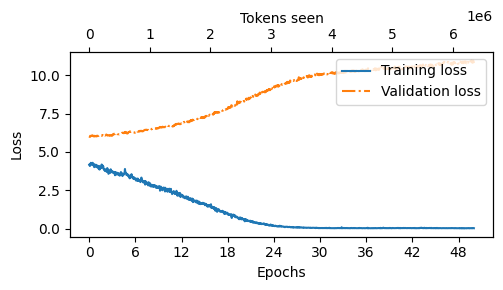

In [45]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)